In [1]:
from data import get_dataloaders
from model import DualGraphModel
from train import train_one_epoch, eval_one_epoch, EarlyStopping
from config import DEVICE, EPOCHS, SAVE_DIR
import torch
import os

In [2]:
train_loader, val_loader, test_loader = get_dataloaders(batch_size=8)

D:\H.Parvin\hashem\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: dee0b9cb-cda2-433b-83a3-e4ddaca7a0da)')' thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: f38969d6-287d-4746-bb96-fdce5c57301b)')' thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/tokenizer_config.json
Retrying in 2s [Retry 2/5].
'(ProtocolError('Connection aborted.', Connectio

In [3]:
model = DualGraphModel(
    num_classes=3,
    weight_roberta=0.5,
    weight_sent=0.3,
    weight_chunk=0.2
).to(DEVICE)

CLASS_NAMES = ["negative", "neutral", "positive"]
NUM_CLASSES = 3
EPOCHS = 20
LR = 2e-5
WEIGHT_DECAY = 0.01
PATIENCE = 10           
MIN_DELTA = 1e-4   
USE_AMP = True

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion = torch.nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler() 
SAVE_DIR = "outputs"
os.makedirs(SAVE_DIR, exist_ok=True)
best_model_path = os.path.join(SAVE_DIR, "best_model.pt")
early_stopper = EarlyStopping(patience=10, min_delta=1e-4, path=best_model_path)

'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 698827d0-4775-4df1-a02e-95761bc64f7d)')' thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 3bdd2880-c52b-49f8-82a8-8d8f7e12a533)')' thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 0873f328-5f94-4258-8ab5-d1dbbdf2febc)')' thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/config.json
Retrying in 4s [Retry 3/5].
'(ProtocolError('Conne

In [4]:
import time
import torch
from torch.cuda.amp import GradScaler
from train import EarlyStopping

scaler = GradScaler(enabled=True)

early_stopping = EarlyStopping(
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    path="best_model.pt"
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_loss = float("inf")
total_start_time = time.time()
print("Training started...\n")

for epoch in range(EPOCHS):
    epoch_start = time.time()

    print(f"Epoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE,
        scaler=scaler,
        use_amp=True
    )

    val_loss, val_acc, _, _ = eval_one_epoch(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    epoch_end = time.time()
    epoch_time = epoch_end - epoch_start

    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"  Epoch Time: {epoch_time:.2f} seconds")

    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

total_end_time = time.time()
total_training_time = total_end_time - total_start_time

minutes = total_training_time // 60
seconds = total_training_time % 60

print("\n==========================")
print("Training Finished")
print(f"Total Training Time: {int(minutes)} min {int(seconds)} sec")
print("==========================\n")


Training started...

Epoch 1/20
  Train Loss: 0.4237 | Train Acc: 0.8398
  Val   Loss: 0.4328 | Val   Acc: 0.8470
  Epoch Time: 160.11 seconds
Epoch 2/20
  Train Loss: 0.2034 | Train Acc: 0.9345
  Val   Loss: 0.5068 | Val   Acc: 0.8497
  Epoch Time: 159.35 seconds
Epoch 3/20
  Train Loss: 0.1278 | Train Acc: 0.9622
  Val   Loss: 0.6107 | Val   Acc: 0.8506
  Epoch Time: 160.35 seconds
Epoch 4/20
  Train Loss: 0.0962 | Train Acc: 0.9719
  Val   Loss: 0.5947 | Val   Acc: 0.8497
  Epoch Time: 161.73 seconds
Epoch 5/20
  Train Loss: 0.0741 | Train Acc: 0.9774
  Val   Loss: 0.6788 | Val   Acc: 0.8438
  Epoch Time: 162.51 seconds
Epoch 6/20
  Train Loss: 0.0637 | Train Acc: 0.9817
  Val   Loss: 0.7388 | Val   Acc: 0.8388
  Epoch Time: 163.37 seconds
Epoch 7/20
  Train Loss: 0.0540 | Train Acc: 0.9849
  Val   Loss: 0.8027 | Val   Acc: 0.8411
  Epoch Time: 163.68 seconds
Epoch 8/20
  Train Loss: 0.0506 | Train Acc: 0.9854
  Val   Loss: 0.7616 | Val   Acc: 0.8429
  Epoch Time: 163.92 seconds
Epo

In [5]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_acc, y_true, y_pred, y_prob = eval_one_epoch(
    model,
    test_loader,
    criterion,
    device=DEVICE,
    return_probs=True
)
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
print("\n=== TEST RESULTS ===")
print(f"Test loss: {test_loss:.4f}")
print(f"Test acc : {test_acc:.4f}")
print(f"Weighted Precision: {prec:.4f}")
print(f"Weighted Recall   : {rec:.4f}")
print(f"Weighted F1       : {f1:.4f}\n")
print("Classification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))



=== TEST RESULTS ===
Test loss: 0.4819
Test acc : 0.8388
Weighted Precision: 0.8536
Weighted Recall   : 0.8388
Weighted F1       : 0.8433

Classification report:
              precision    recall  f1-score   support

    negative     0.9431    0.8548    0.8968      1377
     neutral     0.6540    0.7763    0.7099       465
    positive     0.7677    0.8588    0.8107       354

    accuracy                         0.8388      2196
   macro avg     0.7883    0.8300    0.8058      2196
weighted avg     0.8536    0.8388    0.8433      2196



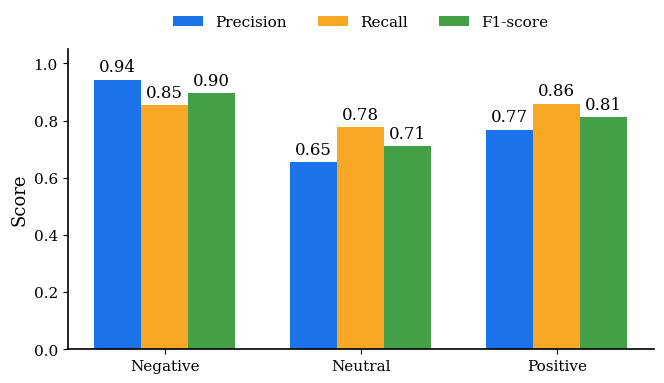

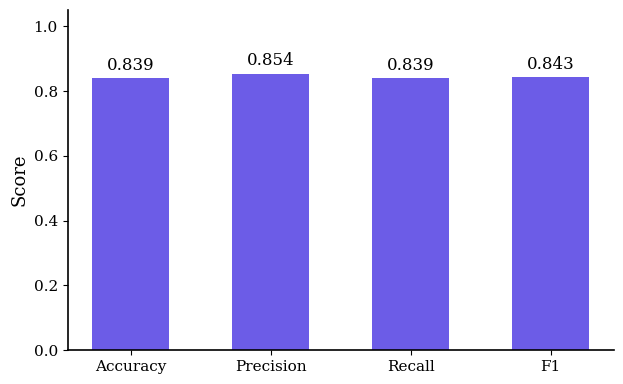

In [3]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['Negative', 'Neutral', 'Positive']
precision = [0.9431, 0.6540, 0.7677]
recall    = [0.8548, 0.7763, 0.8588]
f1_score  = [0.8968, 0.7099, 0.8107]

test_acc           = 0.8388
weighted_precision = 0.8536
weighted_recall    = 0.8388
weighted_f1        = 0.8433

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 1.2,
})

colors = {
    "precision": "#1A73E8",
    "recall":    "#F9A825",
    "f1":        "#43A047",
    "overall":   "#6C5CE7"
}

fig, ax = plt.subplots(figsize=(6.8, 4))

x = np.arange(len(classes))
width = 0.24

p1 = ax.bar(x - width, precision, width, label="Precision", color=colors['precision'])
p2 = ax.bar(x,         recall,    width, label="Recall",    color=colors['recall'])
p3 = ax.bar(x + width, f1_score,  width, label="F1-score",  color=colors['f1'])

ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.05)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bars in [p1, p2, p3]:
    ax.bar_label(bars, fmt="%.2f", padding=3)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.savefig("per_class_metrics_new.png", dpi=500, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6.4, 4))

metrics_names = ["Accuracy", "Precision", "Recall", "F1"]
metrics_values = [test_acc, weighted_precision, weighted_recall, weighted_f1]

bars = ax.bar(metrics_names, metrics_values, color=colors['overall'], width=0.55)

ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.bar_label(bars, fmt="%.3f", padding=3)

plt.tight_layout()
plt.savefig("overall_metrics_new.png", dpi=500, bbox_inches="tight")
plt.show()


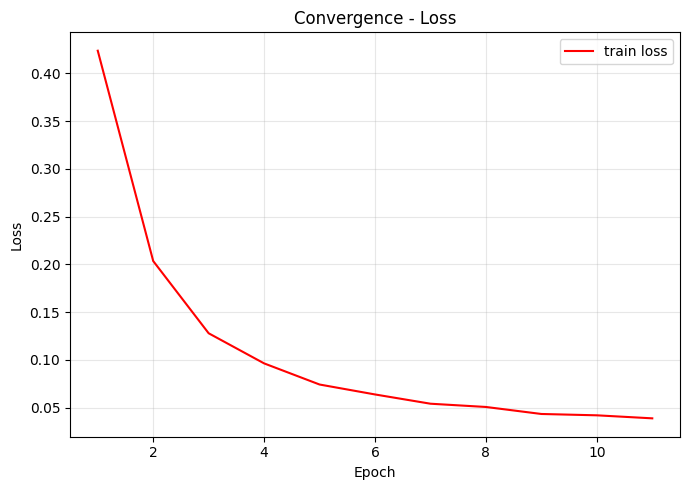

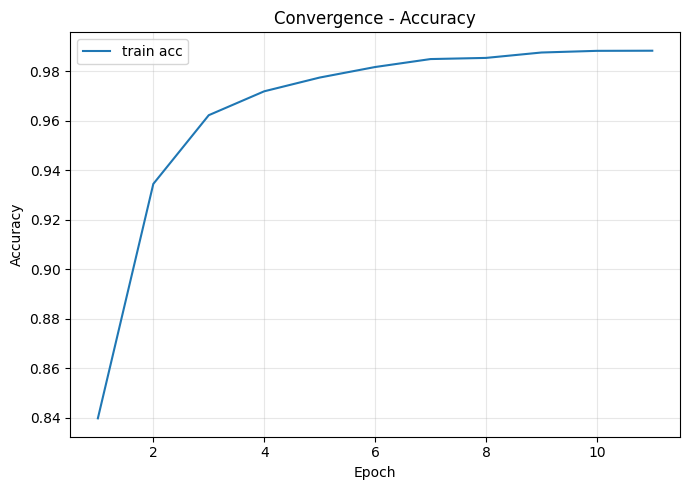

Saved convergence plots to: outputs/convergence_loss.png and convergence_acc.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_convergence(history, save_dir):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7,5))
    plt.plot(epochs, history["train_loss"], label="train loss", color='r')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Convergence - Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()

    path = os.path.join(save_dir, "convergence_loss.png")
    plt.tight_layout()
    plt.savefig(path, dpi=500)

    plt.show()   
    plt.close()

    plt.figure(figsize=(7,5))
    plt.plot(epochs, history["train_acc"], label="train acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Convergence - Accuracy")
    plt.grid(True, alpha=0.3)
    plt.legend()

    path = os.path.join(save_dir, "convergence_acc.png")
    plt.tight_layout()
    plt.savefig(path, dpi=500)

    plt.show()   
    plt.close()

plot_convergence(history, SAVE_DIR)

print(f"Saved convergence plots to: {SAVE_DIR}/convergence_loss.png and convergence_acc.png")


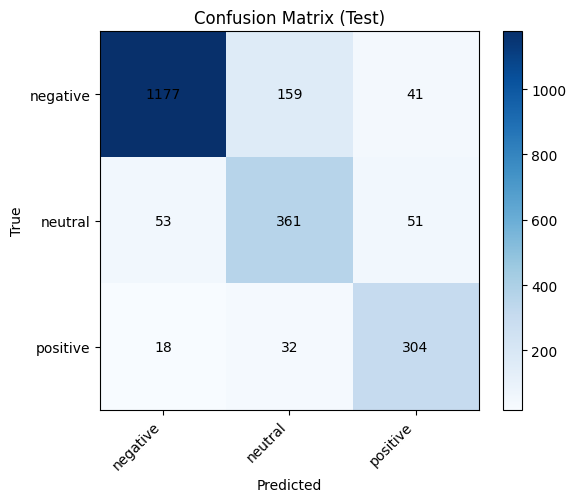

Saved confusion matrix to: outputs/confusion_matrix.png
Confusion matrix:
 [[1177  159   41]
 [  53  361   51]
 [  18   32  304]]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import os

def plot_confusion_matrix(y_true, y_pred, class_names, save_dir):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))

    plt.imshow(cm, cmap="Blues")
    plt.colorbar()

    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(class_names)), class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (Test)")
    plt.tight_layout()

    path = os.path.join(save_dir, "confusion_matrix.png")
    plt.savefig(path, dpi=500)

    plt.show()

    plt.close()
    return cm

cm = plot_confusion_matrix(y_true, y_pred, CLASS_NAMES, SAVE_DIR)
print(f"Saved confusion matrix to: {SAVE_DIR}/confusion_matrix.png")
print("Confusion matrix:\n", cm)


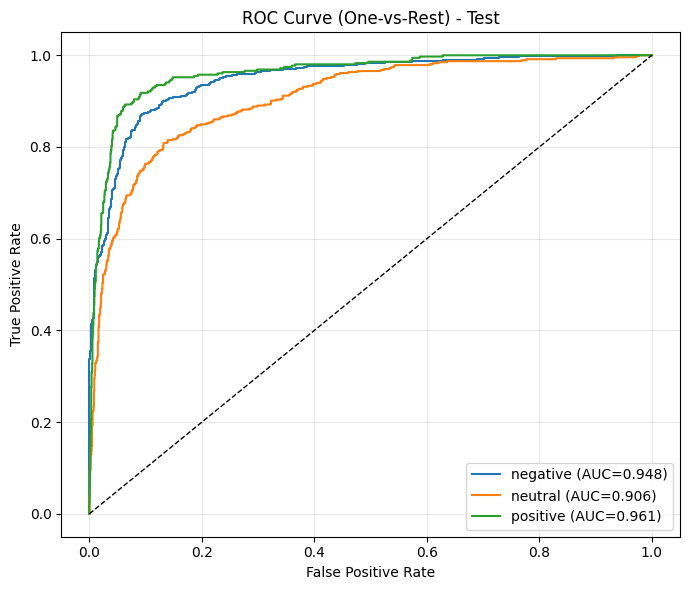

Saved ROC plot to: outputs/roc_ovr.png


In [8]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_roc_ovr(y_true, y_prob, num_classes, class_names, save_dir):

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    y_true_oh = np.eye(num_classes)[y_true]  # shape [N, C]

    plt.figure(figsize=(7,6))

    for c in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_oh[:, c], y_prob[:, c])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[c]} (AUC={roc_auc:.3f})")

    plt.plot([0,1], [0,1], "k--", linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (One-vs-Rest) - Test")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    path = os.path.join(save_dir, "roc_ovr.png")
    plt.savefig(path, dpi=500)

    plt.show()   

plot_roc_ovr(y_true, y_prob, NUM_CLASSES, CLASS_NAMES, SAVE_DIR)
print(f"Saved ROC plot to: {SAVE_DIR}/roc_ovr.png")


In [11]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import accuracy_score, f1_score

device = DEVICE  

best_path = os.path.join(SAVE_DIR, "best_model.pt")

ablation_configs = [
    {"name": "Full Model",        "r":0.5, "s":0.3, "c":0.2},
    {"name": "No Roberta",        "r":0.0, "s":0.3, "c":0.2},
    {"name": "Only Chunk",        "r":0.0, "s":0.0, "c":0.2},
    {"name": "Only Sentence",     "r":0.0, "s":0.3, "c":0.0},
    {"name": "None (Zero)",       "r":0.0, "s":0.0, "c":0.0},
]

results = []

print("\nRunning Ablation Study...\n")

for cfg in ablation_configs:

    print(f"Testing: {cfg['name']}")

    m = DualGraphModel(
        num_classes=NUM_CLASSES,
        weight_roberta=cfg["r"],
        weight_sent=cfg["s"],
        weight_chunk=cfg["c"]
    ).to(device)

    m.load_state_dict(torch.load(best_path, map_location=device))
    m.eval()

    val_loss, val_acc, y_true, y_pred = eval_one_epoch(
        model=m,
        data_loader=test_loader,
        criterion=criterion,
        device=device,
        return_probs=False
    )

    acc = accuracy_score(y_true, y_pred)
    f1w = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    results.append({
        "Config": cfg["name"],
        "Accuracy": acc,
        "F1_weighted": f1w
    })

ablation_df = pd.DataFrame(results)
ablation_df = ablation_df.sort_values(by="F1_weighted", ascending=False).reset_index(drop=True)

print("\n=== Ablation Study Results ===")
print(ablation_df.to_string(index=False))

plt.figure(figsize=(10,5))
x = np.arange(len(ablation_df))
bar_w = 0.35

plt.bar(x - bar_w/2, ablation_df["Accuracy"],     width=bar_w, label="Accuracy",     color="#1f77b4")
plt.bar(x + bar_w/2, ablation_df["F1_weighted"],  width=bar_w, label="F1-Weighted",  color="#ff7f0e")

plt.xticks(x, ablation_df["Config"], rotation=25, ha="right")
plt.ylabel("Score")
plt.title("Ablation Study – Effect of Removing Components")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

save_path = os.path.join(SAVE_DIR, "ablation_study.png")
plt.savefig(save_path, dpi=500)
plt.close()

print(f"\nSaved ablation chart to: {save_path}")



Running Ablation Study...

Testing: Full Model


D:\H.Parvin\hashem\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing: No Roberta


D:\H.Parvin\hashem\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing: Only Chunk


...

Testing: Only Sentence


D:\H.Parvin\hashem\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing: None (Zero)


D:\H.Parvin\hashem\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



=== Ablation Study Results ===
       Config  Accuracy  F1_weighted
   Full Model  0.838798     0.843322
Only Sentence  0.826047     0.832527
   No Roberta  0.816485     0.824657
   Only Chunk  0.720401     0.738033
  None (Zero)  0.161202     0.044757

Saved ablation chart to: outputs\ablation_study.png
